In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set some default styles for our plots
sns.set_style('whitegrid')
%matplotlib inline

In [3]:
# Load the CSV file into a pandas DataFrame
df = pd.read_csv('sales_data.csv')

# Display the first 5 rows to confirm it loaded correctly
df.head()

,SaleID,SaleDate,ProductName,ProductCategory,CustomerName,CustomerEmail,CustomerRegion,SaleAmount,SellerName
0,533e605d-7da4-4c64-a772-5e29e295a0de,2025-09-07 04:13:00,Jacket,Clothing,Tyler Randall,brandon95@example.org,East,20.56,Catherine Long
1,d1fdf893-1eb9-4c64-af02-a26fdfbd1aa8,2024-06-01 15:18:46,Smartwatch,Electronics,Kevin Thomas,beckerjennifer@example.com,West,722.63,Shannon Lee
2,60e25092-6beb-4607-9371-4e3773d0eaaa,2024-01-19 09:13:46,Smartwatch,Electronics,Tamara Christensen,sonya14@example.net,South,839.97,Mitchell Rogers
3,27ed9f6f-fd17-460b-800d-365a213674f9,2025-09-10 22:59:15,Jeans,Clothing,Dawn Fields,wmoreno@example.com,East,532.59,Kristin Brown
4,207dccfb-24e5-453f-80cc-58968e61b977,2024-12-07 11:58:05,Cookbook,Books,Jessica Thompson,egeorge@example.com,West,283.06,Tiffany Graham


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 9 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   SaleID           300000 non-null  object 
 1   SaleDate         300000 non-null  object 
 2   ProductName      300000 non-null  object 
 3   ProductCategory  300000 non-null  object 
 4   CustomerName     300000 non-null  object 
 5   CustomerEmail    300000 non-null  object 
 6   CustomerRegion   300000 non-null  object 
 7   SaleAmount       300000 non-null  float64
 8   SellerName       300000 non-null  object 
dtypes: float64(1), object(8)
memory usage: 20.6+ MB


In [5]:
# Convert 'SaleDate' from a string to a datetime object
df['SaleDate'] = pd.to_datetime(df['SaleDate'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 9 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   SaleID           300000 non-null  object        
 1   SaleDate         300000 non-null  datetime64[ns]
 2   ProductName      300000 non-null  object        
 3   ProductCategory  300000 non-null  object        
 4   CustomerName     300000 non-null  object        
 5   CustomerEmail    300000 non-null  object        
 6   CustomerRegion   300000 non-null  object        
 7   SaleAmount       300000 non-null  float64       
 8   SellerName       300000 non-null  object        
dtypes: datetime64[ns](1), float64(1), object(7)
memory usage: 20.6+ MB


In [6]:
df.describe()

,SaleDate,SaleAmount
count,300000,300000.000000
mean,2024-09-15 04:58:40.032406784,455.258471
min,2023-09-16 07:11:12,10.510000
25%,2024-03-16 18:19:51.500000,233.140000
50%,2024-09-15 01:35:27.500000,454.920000
75%,2025-03-16 08:00:37,678.172500
max,2025-09-15 18:39:38,899.990000
std,NaN,256.859634


In [7]:
# Get descriptive statistics for categorical (object) columns
df.describe(include='object')

,SaleID,ProductName,ProductCategory,CustomerName,CustomerEmail,CustomerRegion,SellerName
count,300000,300000,300000,300000,300000,300000,300000
unique,300000,20,5,159354,215716,4,10
top,533e605d-7da4-4c64-a772-5e29e295a0de,Yoga Mat,Sports,Michael Smith,csmith@example.com,South,Christina Powell
freq,1,15242,60327,144,37,75346,30175


In [8]:
# Check if there are any null values in our dataset
df.isnull().sum()

SaleID             0
SaleDate           0
ProductName        0
ProductCategory    0
CustomerName       0
CustomerEmail      0
CustomerRegion     0
SaleAmount         0
SellerName         0
dtype: int64

In [9]:
# Set the SaleDate as the index for time-series analysis
df.set_index('SaleDate', inplace=True)
df.head()

,SaleID,ProductName,ProductCategory,CustomerName,CustomerEmail,CustomerRegion,SaleAmount,SellerName
SaleDate,,,,,,,,
2025-09-07 04:13:00,533e605d-7da4-4c64-a772-5e29e295a0de,Jacket,Clothing,Tyler Randall,brandon95@example.org,East,20.56,Catherine Long
2024-06-01 15:18:46,d1fdf893-1eb9-4c64-af02-a26fdfbd1aa8,Smartwatch,Electronics,Kevin Thomas,beckerjennifer@example.com,West,722.63,Shannon Lee
2024-01-19 09:13:46,60e25092-6beb-4607-9371-4e3773d0eaaa,Smartwatch,Electronics,Tamara Christensen,sonya14@example.net,South,839.97,Mitchell Rogers
2025-09-10 22:59:15,27ed9f6f-fd17-460b-800d-365a213674f9,Jeans,Clothing,Dawn Fields,wmoreno@example.com,East,532.59,Kristin Brown
2024-12-07 11:58:05,207dccfb-24e5-453f-80cc-58968e61b977,Cookbook,Books,Jessica Thompson,egeorge@example.com,West,283.06,Tiffany Graham


### What are the sales trends over time?

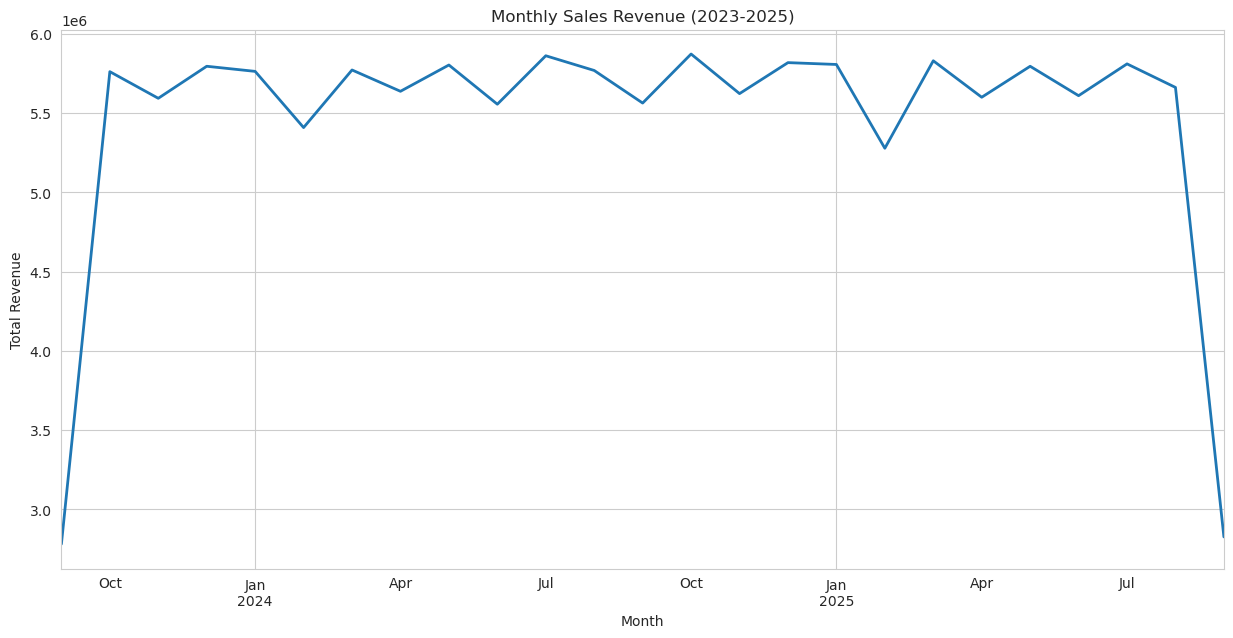

In [10]:
# Resample the data by month ('M') and sum the SaleAmount for each month
monthly_sales = df['SaleAmount'].resample('M').sum()

# Create the plot
plt.figure(figsize=(15, 7))
monthly_sales.plot(title='Monthly Sales Revenue (2023-2025)', lw=2)
plt.ylabel('Total Revenue')
plt.xlabel('Month')
plt.show()

### Which product categories generate the most revenue?

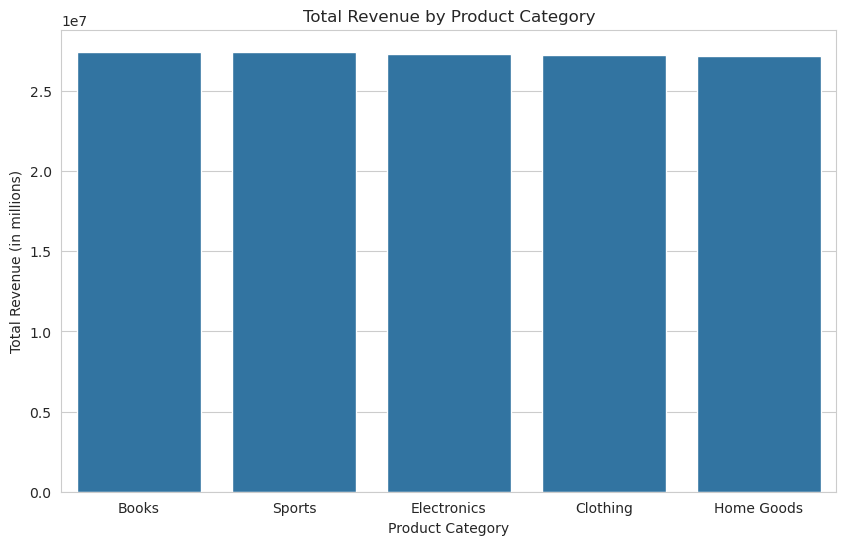

In [11]:
# Group by category and sum the sales amount, then sort
category_revenue = df.groupby('ProductCategory')['SaleAmount'].sum().sort_values(ascending=False)

# Create the plot
plt.figure(figsize=(10, 6))
sns.barplot(x=category_revenue.index, y=category_revenue.values)
plt.title('Total Revenue by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Revenue (in millions)')
plt.show()

### Who are the top 10 performing sellers?

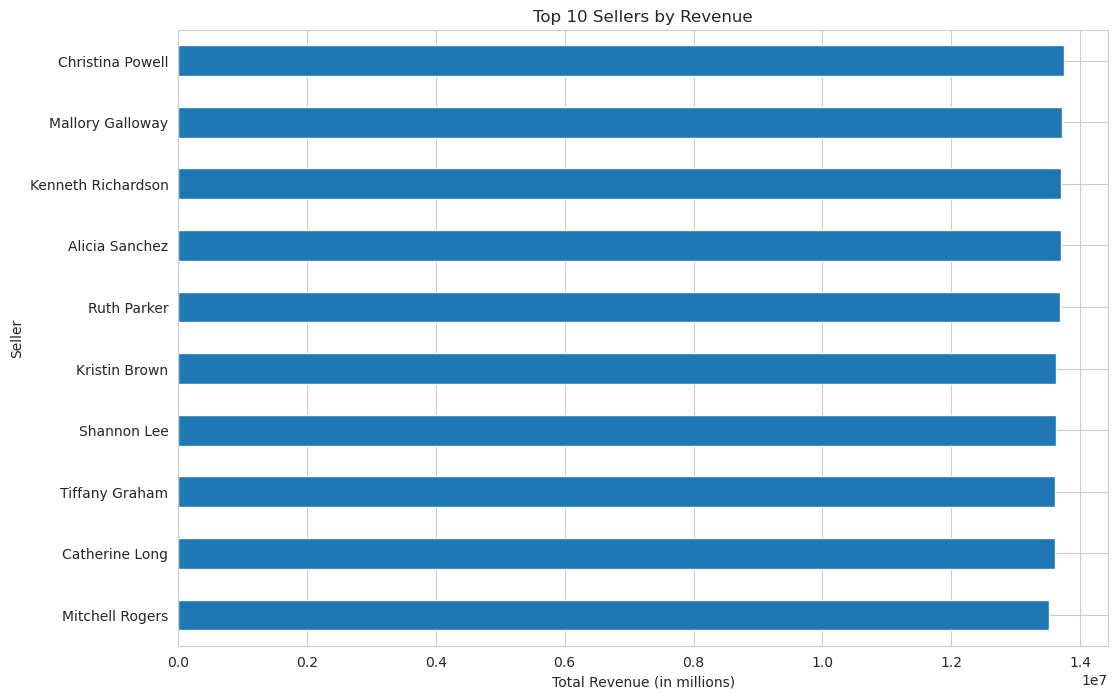

In [12]:
# Group by seller, sum the sales, and get the top 10
top_sellers = df.groupby('SellerName')['SaleAmount'].sum().nlargest(10).sort_values(ascending=True)

# Create the plot
plt.figure(figsize=(12, 8))
top_sellers.plot(kind='barh', title='Top 10 Sellers by Revenue')
plt.xlabel('Total Revenue (in millions)')
plt.ylabel('Seller')
plt.show()

### What is the sales distribution by customer region?

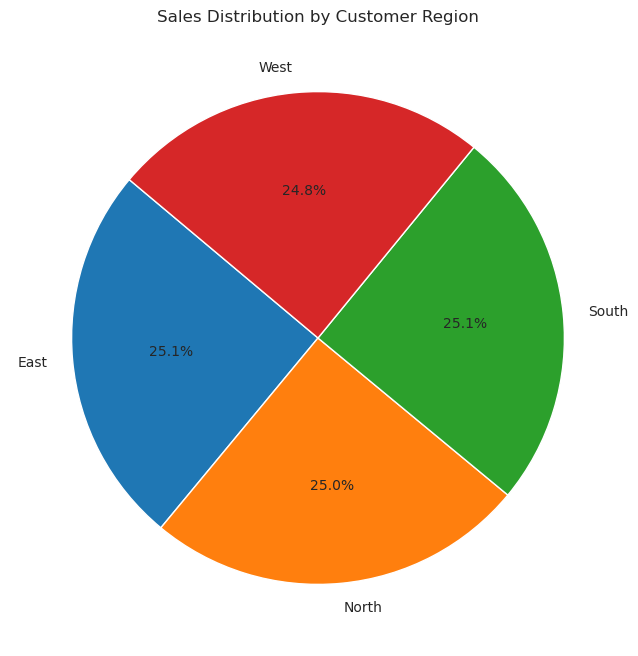

In [13]:
# Group by region and sum the sales
region_sales = df.groupby('CustomerRegion')['SaleAmount'].sum()

# Create the plot
plt.figure(figsize=(8, 8))
plt.pie(region_sales, labels=region_sales.index, autopct='%1.1f%%', startangle=140)
plt.title('Sales Distribution by Customer Region')
plt.ylabel('') # Hide the default 'SaleAmount' label
plt.show()

### What is the distribution of individual sale amounts?

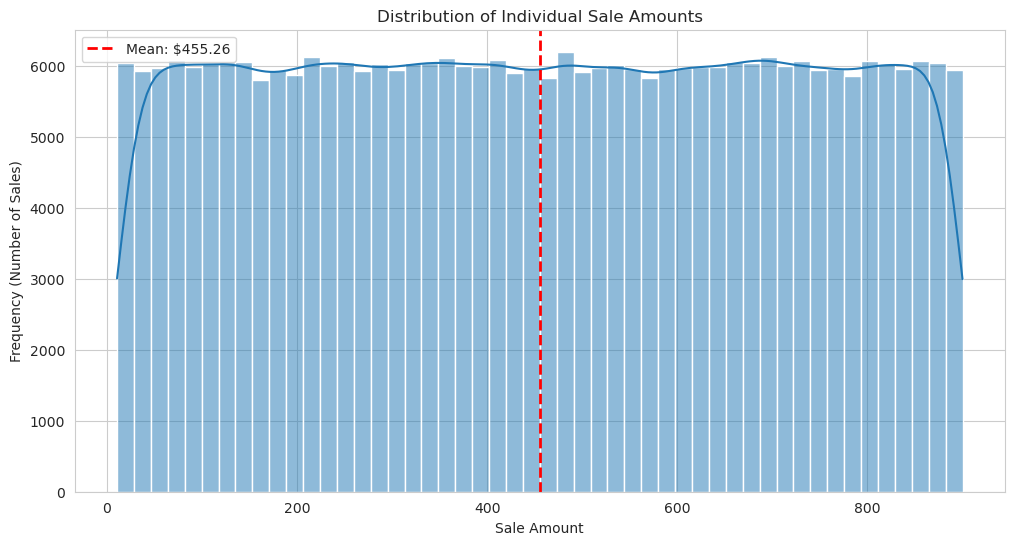

In [14]:
# Create a histogram of the SaleAmount
plt.figure(figsize=(12, 6))
sns.histplot(df['SaleAmount'], bins=50, kde=True)
plt.title('Distribution of Individual Sale Amounts')
plt.xlabel('Sale Amount')
plt.ylabel('Frequency (Number of Sales)')
# Add a vertical line for the mean sale amount
plt.axvline(df['SaleAmount'].mean(), color='red', linestyle='--', lw=2, label=f"Mean: ${df['SaleAmount'].mean():.2f}")
plt.legend()
plt.show()

### Do some categories have more transactions than others?

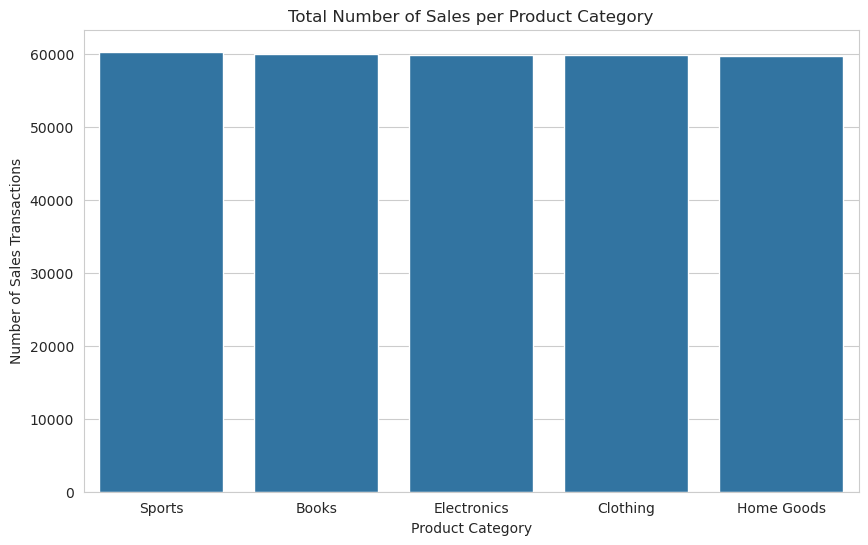

In [15]:
# To do this analysis, we need the original DataFrame before we set the index.
# Let's reset the index to get SaleDate back as a column for a moment.
df_reset = df.reset_index()

plt.figure(figsize=(10, 6))
sns.countplot(x='ProductCategory', data=df_reset, order=df_reset['ProductCategory'].value_counts().index)
plt.title('Total Number of Sales per Product Category')
plt.xlabel('Product Category')
plt.ylabel('Number of Sales Transactions')
plt.show()

### Are there sales patterns based on the day of the week?

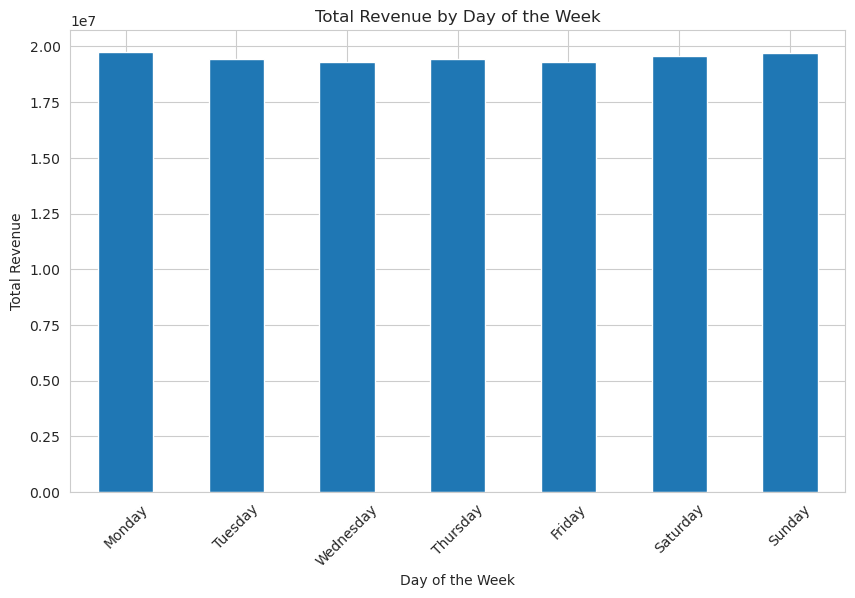

In [16]:
# Extract the day of the week name from the index
df['DayOfWeek'] = df.index.day_name()

# Define the correct order for the days of the week
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
sales_by_day = df.groupby('DayOfWeek')['SaleAmount'].sum().reindex(day_order)

# Create the plot
plt.figure(figsize=(10, 6))
sales_by_day.plot(kind='bar', title='Total Revenue by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.show()

## Conclusion

The initial analysis reveals that sales revenue and transaction counts are almost perfectly uniformly distributed across product categories, sellers, regions, and time. There are no observable trends, seasonality, or performance differences. This is a strong indicator of synthetically generated data. While this dataset is excellent for testing the application's performance and functionality, the insights derived do not reflect real-world customer behavior. To develop a meaningful business strategy, we would require actual sales data.